In [1]:
import pandas as pd

files = [
    "/content/q8_24_lut_results.csv",
    "/content/q8_24_interp_results.csv",
    "/content/q8_24_nr_results.csv",
    "/content/q8_24_gs_results.csv",
    "/content/q8_24_hybrid_results.csv"
]

for path in files:

    print("\n" + "=" * 80)
    print(path)

    df = pd.read_csv(path, nrows=5)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nFirst 5 rows:")
    print(df.to_string(index=False))


/content/q8_24_lut_results.csv

Columns:
['idx', 'x_hex', 'golden_hex', 'hw_hex', 'abs_err_lsb', 'relative_err']

First 5 rows:
 idx  x_hex golden_hex  hw_hex  abs_err_lsb  relative_err
   0 800000   02000000 2000000            0      0.000000
   1 800022   01ffff78 2000000          136      0.000004
   2 800043   01fffef4 2000000          268      0.000008
   3 800065   01fffe6c 2000000          404      0.000012
   4 800086   01fffde8 2000000          536      0.000016

/content/q8_24_interp_results.csv

Columns:
['idx', 'x_hex', 'golden_hex', 'hw_hex', 'abs_err_lsb', 'relative_err']

First 5 rows:
 idx  x_hex golden_hex  hw_hex  abs_err_lsb  relative_err
   0 800000   02000000 2000000            0      0.000000
   1 800022   01ffff78 2000000          136      0.000004
   2 800043   01fffef4 2000000          268      0.000008
   3 800065   01fffe6c 2000000          404      0.000012
   4 800086   01fffde8 2000000          536      0.000016

/content/q8_24_nr_results.csv

Columns:
['

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILES = {
    "Direct LUT": "/content/q8_24_lut_results.csv",
    "Interpolation": "/content/q8_24_interp_results.csv",
    "Newton-Raphson": "/content/q8_24_nr_results.csv",
    "Goldschmidt": "/content/q8_24_gs_results.csv",
    "Hybrid": "/content/q8_24_hybrid_results.csv"
}

WARMUP = {
    "Direct LUT": 0,
    "Interpolation": 0,
    "Newton-Raphson": 24,
    "Goldschmidt": 24,
    "Hybrid": 0
}

LINESTYLES = {
    "Direct LUT": "-",
    "Interpolation": "--",
    "Newton-Raphson": "-.",
    "Goldschmidt": ":",
    "Hybrid": (0, (5, 1))
}

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "figure.dpi": 160,
    "savefig.dpi": 600
})

def load_valid(name):
    df = pd.read_csv(FILES[name])
    warmup = WARMUP[name]
    if warmup > 0:
        df = df.iloc[warmup:].copy()
    return df

def hex_to_int(series):
    return series.astype(str).map(lambda x: int(x, 16)).to_numpy()

def get_error(df):
    if "abs_err_lsb" in df.columns:
        return df["abs_err_lsb"].to_numpy(dtype=float)
    raise ValueError("abs_err_lsb column not found")

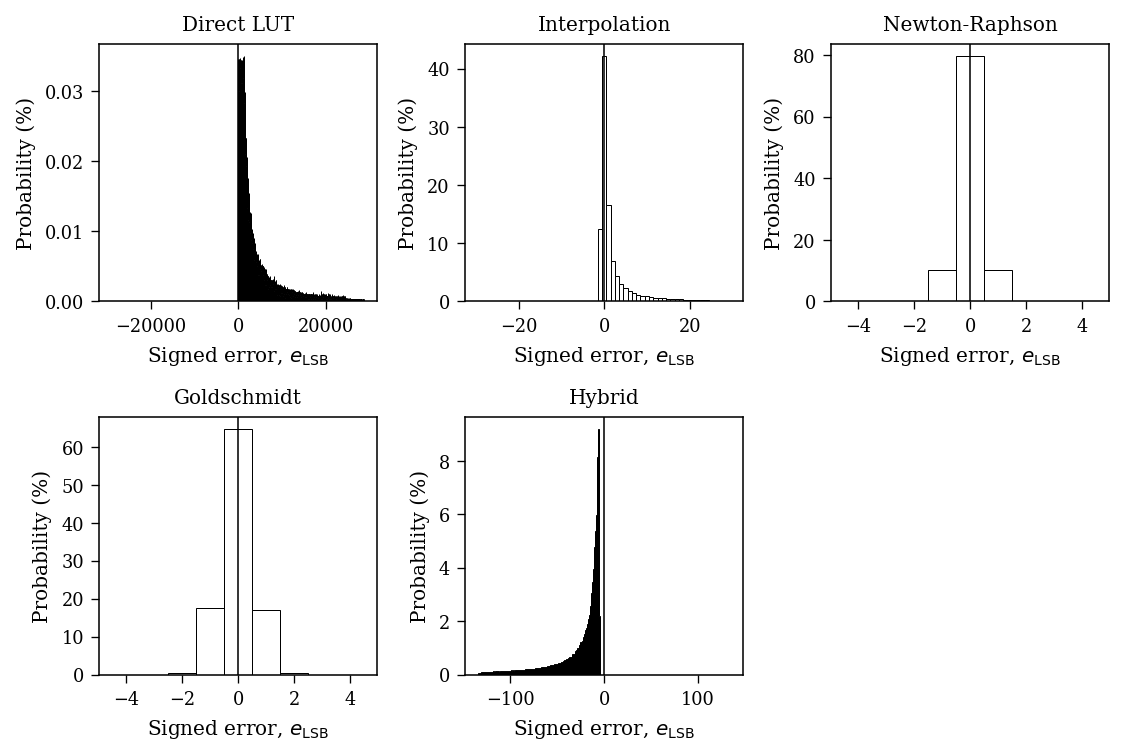

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(7.1, 4.8))
axes = axes.flatten()

for ax, name in zip(axes, FILES):
    df = load_valid(name)
    golden = hex_to_int(df["golden_hex"])
    hw = hex_to_int(df["hw_hex"])
    error = hw - golden
    lim = max(
        4,
        int(np.ceil(np.percentile(np.abs(error), 99.9)))
    )
    edges = np.arange(
        -lim - 0.5,
        lim + 1.5,
        1
    )
    weights = np.ones(len(error)) * 100.0 / len(error)
    ax.hist(
        error,
        bins=edges,
        weights=weights,
        color="white",
        edgecolor="black",
        linewidth=0.45
    )
    ax.axvline(
        0,
        color="black",
        linewidth=0.7
    )
    ax.set_title(name)
    ax.set_xlabel(r"Signed error, $e_{\mathrm{LSB}}$")
    ax.set_ylabel("Probability (%)")
    ax.grid(False)

axes[-1].axis("off")
fig.tight_layout()

fig.savefig(
    "fig1_signed_error_histograms.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

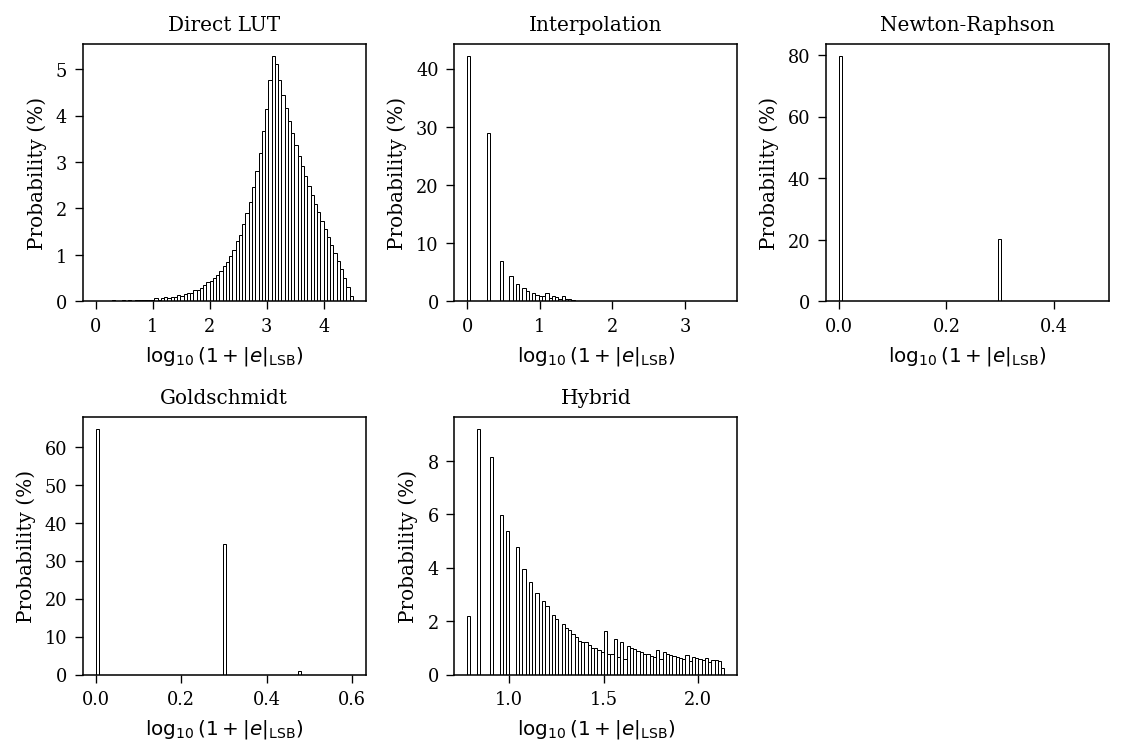

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(7.1, 4.8))
axes = axes.flatten()

for ax, name in zip(axes, FILES):
    df = load_valid(name)
    error = get_error(df)
    error = error[np.isfinite(error)]
    error = np.maximum(error, 0)
    transformed = np.log10(error + 1.0)
    bins = np.linspace(
        transformed.min(),
        transformed.max(),
        80
    )
    weights = np.ones(len(transformed)) * 100.0 / len(transformed)
    ax.hist(
        transformed,
        bins=bins,
        weights=weights,
        color="white",
        edgecolor="black",
        linewidth=0.45
    )
    ax.set_title(name)
    ax.set_xlabel(r"$\log_{10}(1+|e|_{\mathrm{LSB}})$")
    ax.set_ylabel("Probability (%)")
    ax.grid(False)

axes[-1].axis("off")
fig.tight_layout()

fig.savefig(
    "fig2_absolute_error_histograms.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

/tmp/ipykernel_554/1277806401.py:88: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(


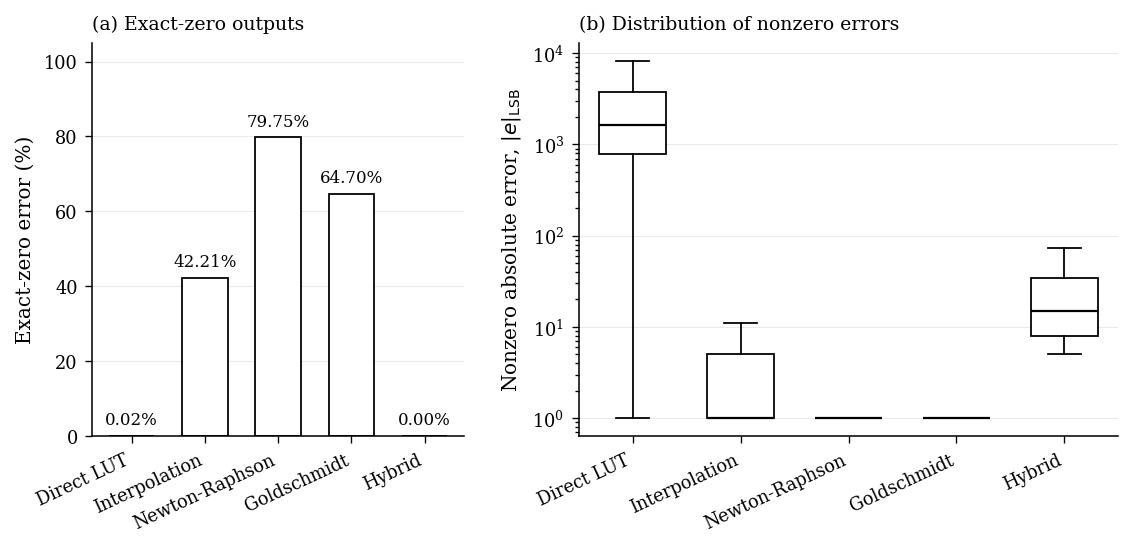

In [5]:
import numpy as np
import matplotlib.pyplot as plt

data_nonzero = []
zero_percent = []
labels = []

for name in FILES:
    df = load_valid(name)
    error = np.asarray(get_error(df), dtype=float)
    error = np.abs(error)
    zero_count = np.count_nonzero(error == 0)
    total_count = len(error)
    zero_pct = 100.0 * zero_count / total_count
    nonzero_error = error[error > 0]
    data_nonzero.append(nonzero_error)
    zero_percent.append(zero_pct)
    labels.append(name)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(7.16, 3.5),
    gridspec_kw={"width_ratios": [1, 1.45]}
)

ax0, ax1 = axes
x = np.arange(len(labels))
bars = ax0.bar(
    x,
    zero_percent,
    width=0.62,
    edgecolor="black",
    facecolor="white",
    linewidth=0.8
)

ax0.set_xticks(x)
ax0.set_xticklabels(
    labels,
    rotation=25,
    ha="right"
)
ax0.set_ylabel(
    "Exact-zero error (%)"
)
ax0.set_ylim(
    0,
    105
)
ax0.grid(
    axis="y",
    linewidth=0.35,
    alpha=0.35
)
ax0.set_axisbelow(True)

for bar, pct in zip(bars, zero_percent):
    ax0.text(
        bar.get_x() + bar.get_width() / 2,
        min(pct + 2, 102),
        f"{pct:.2f}%",
        ha="center",
        va="bottom",
        fontsize=7.5
    )

ax0.set_title(
    "(a) Exact-zero outputs",
    loc="left",
    fontsize=8.5
)

bp = ax1.boxplot(
    data_nonzero,
    tick_labels=labels,
    patch_artist=True,
    showfliers=False,
    widths=0.62,
    medianprops={
        "color": "black",
        "linewidth": 1.0
    },
    boxprops={
        "facecolor": "white",
        "edgecolor": "black",
        "linewidth": 0.8
    },
    whiskerprops={
        "color": "black",
        "linewidth": 0.8
    },
    capprops={
        "color": "black",
        "linewidth": 0.8
    }
)

ax1.set_yscale("log")
ax1.set_ylabel(
    r"Nonzero absolute error, $|e|_{\mathrm{LSB}}$"
)
ax1.grid(
    axis="y",
    linewidth=0.35,
    alpha=0.35
)
ax1.set_axisbelow(True)
ax1.set_title(
    "(b) Distribution of nonzero errors",
    loc="left",
    fontsize=8.5
)
ax1.tick_params(
    axis="both",
    labelsize=8
)
ax0.tick_params(
    axis="both",
    labelsize=8
)
ax1.set_xticklabels(
    labels,
    rotation=25,
    ha="right"
)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(
        width=0.6,
        length=3
    )

fig.tight_layout(
    w_pad=1.8
)

fig.savefig(
    "fig3_error_distribution.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

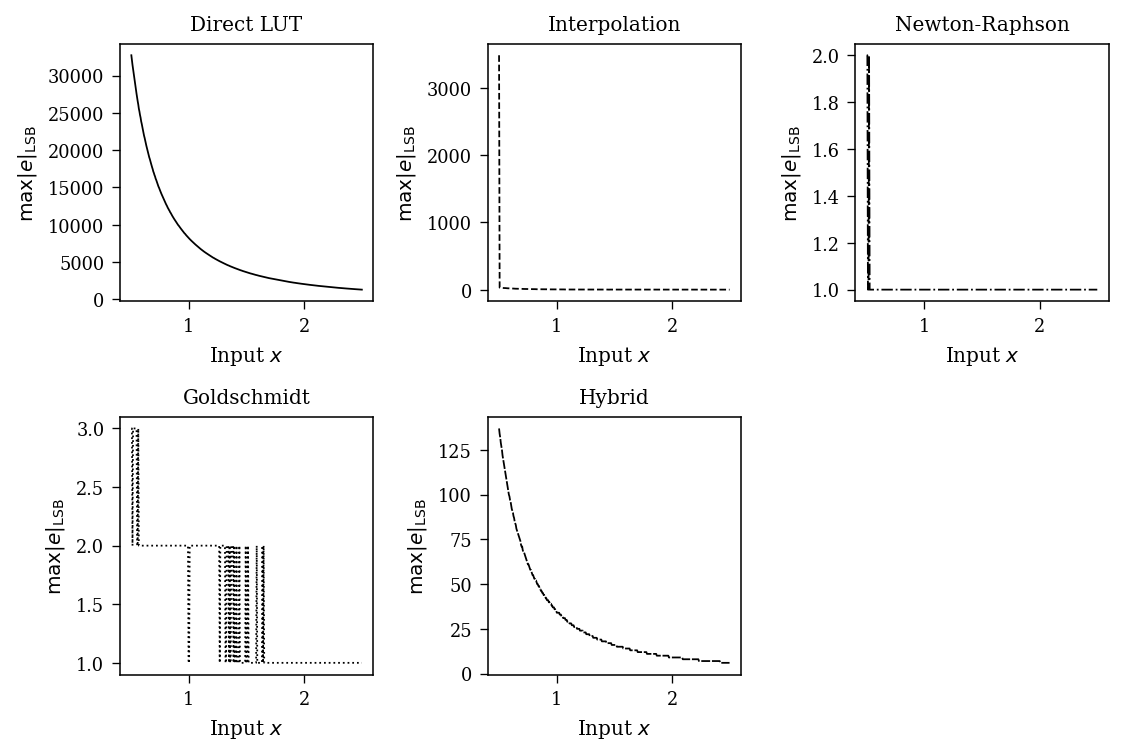

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(7.1, 4.8))
axes = axes.flatten()

for ax, name in zip(axes, FILES):
    df = load_valid(name)
    x = hex_to_int(df["x_hex"]) / 2**24
    error = get_error(df)
    order = np.argsort(x)
    x = x[order]
    error = error[order]
    bins = np.linspace(
        x.min(),
        x.max(),
        401
    )
    centers = (
        bins[:-1] +
        bins[1:]
    ) / 2
    indices = np.digitize(
        x,
        bins
    ) - 1
    worst = np.full(
        len(centers),
        np.nan
    )
    for k in range(len(centers)):
        mask = indices == k
        if np.any(mask):
            worst[k] = np.max(error[mask])
    ax.plot(
        centers,
        worst,
        color="black",
        linestyle=LINESTYLES[name],
        linewidth=0.8
    )
    ax.set_title(name)
    ax.set_xlabel(r"Input $x$")
    ax.set_ylabel(
        r"$\max |e|_{\mathrm{LSB}}$"
    )
    ax.grid(False)

axes[-1].axis("off")
fig.tight_layout()

fig.savefig(
    "fig4_worst_error_vs_input.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

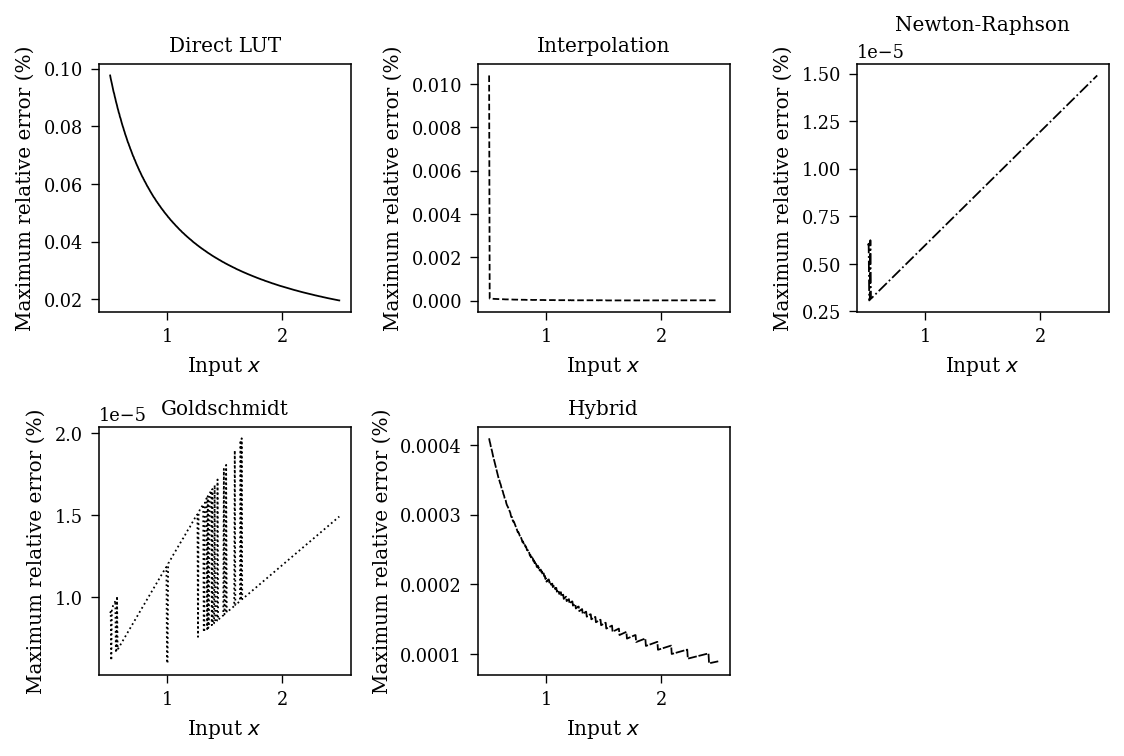

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(7.1, 4.8))
axes = axes.flatten()

for ax, name in zip(axes, FILES):
    df = load_valid(name)
    x = hex_to_int(df["x_hex"]) / 2**24
    golden = (
        hex_to_int(df["golden_hex"])
        / 2**24
    )
    hw = (
        hex_to_int(df["hw_hex"])
        / 2**24
    )
    relative_error = (
        np.abs(hw - golden)
        / np.maximum(np.abs(golden), 1e-30)
    ) * 100
    order = np.argsort(x)
    x = x[order]
    relative_error = relative_error[order]
    bins = np.linspace(
        x.min(),
        x.max(),
        401
    )
    centers = (
        bins[:-1] +
        bins[1:]
    ) / 2
    indices = np.digitize(
        x,
        bins
    ) - 1
    profile = np.full(
        len(centers),
        np.nan
    )
    for k in range(len(centers)):
        mask = indices == k
        if np.any(mask):
            profile[k] = np.max(
                relative_error[mask]
            )
    ax.plot(
        centers,
        profile,
        color="black",
        linestyle=LINESTYLES[name],
        linewidth=0.8
    )
    ax.set_title(name)
    ax.set_xlabel(r"Input $x$")
    ax.set_ylabel(
        "Maximum relative error (%)"
    )
    ax.grid(False)

axes[-1].axis("off")
fig.tight_layout()

fig.savefig(
    "fig5_relative_error_vs_input.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

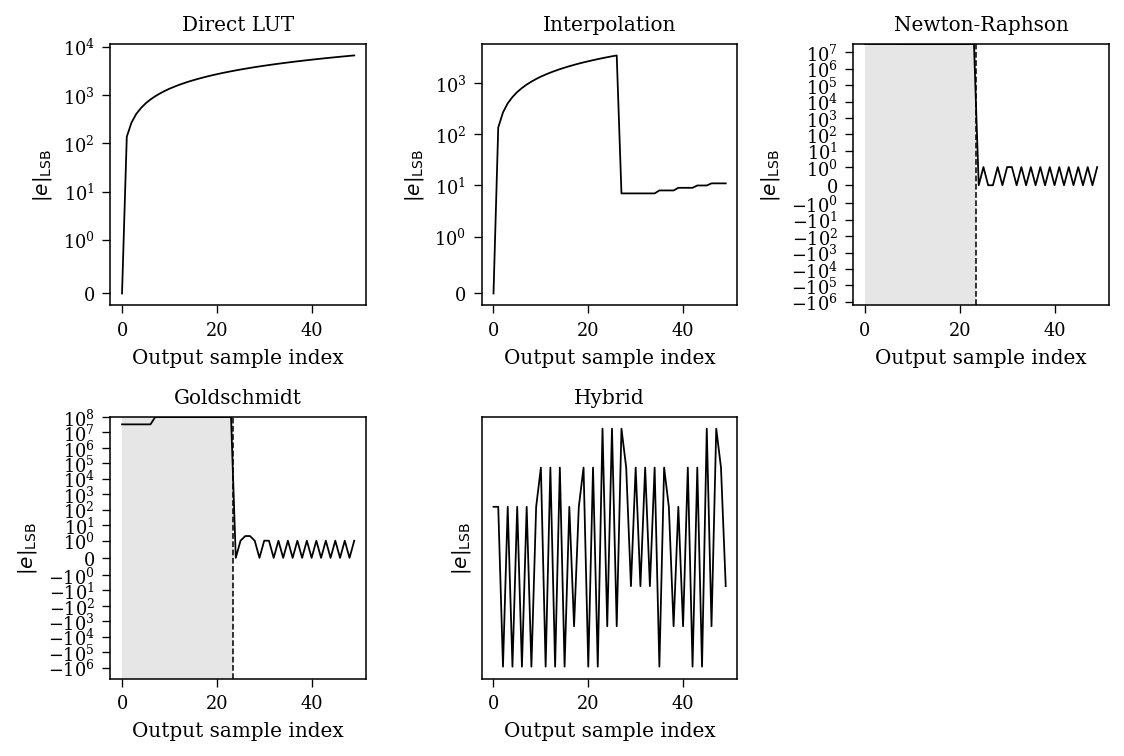

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(7.1, 4.8))
axes = axes.flatten()

for ax, name in zip(axes, FILES):
    df = pd.read_csv(FILES[name])
    warmup = WARMUP[name]
    n = min(
        len(df),
        max(warmup + 20, 50)
    )
    df = df.iloc[:n]
    error = get_error(df)
    indices = np.arange(len(error))
    ax.plot(
        indices,
        error,
        color="black",
        linewidth=0.8
    )
    if warmup > 0:
        ax.axvline(
            warmup - 0.5,
            color="black",
            linestyle="--",
            linewidth=0.7
        )
        ax.axvspan(
            0,
            warmup - 0.5,
            facecolor="0.90",
            edgecolor="none"
        )
    ax.set_yscale(
        "symlog",
        linthresh=1
    )
    ax.set_title(name)
    ax.set_xlabel("Output sample index")
    ax.set_ylabel(
        r"$|e|_{\mathrm{LSB}}$"
    )
    ax.grid(False)

axes[-1].axis("off")
fig.tight_layout()

fig.savefig(
    "fig6_pipeline_warmup.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

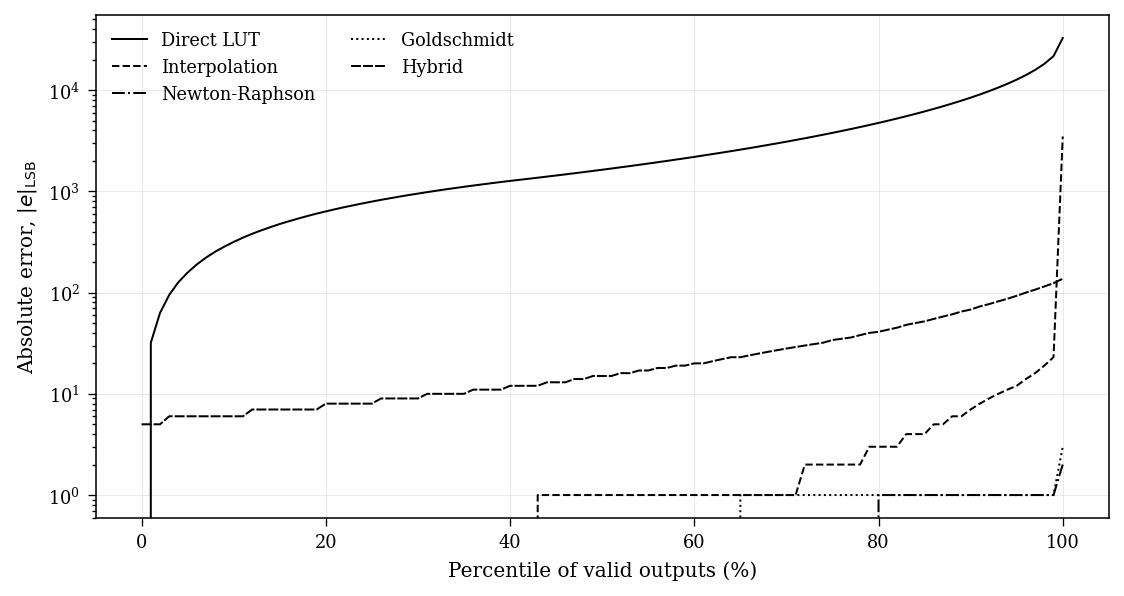

In [9]:
percentiles = np.linspace(
    0,
    100,
    101
)
fig, ax = plt.subplots(
    figsize=(7.1, 3.8)
)

for name in FILES:
    df = load_valid(name)
    error = get_error(df)
    values = np.percentile(
        error,
        percentiles
    )
    ax.plot(
        percentiles,
        values,
        color="black",
        linestyle=LINESTYLES[name],
        linewidth=0.9,
        label=name
    )

ax.set_yscale("log")
ax.set_xlabel(
    "Percentile of valid outputs (%)"
)
ax.set_ylabel(
    r"Absolute error, $|e|_{\mathrm{LSB}}$"
)
ax.grid(
    axis="both",
    linewidth=0.35,
    alpha=0.35
)
ax.set_axisbelow(True)
ax.legend(
    frameon=False,
    ncol=2,
    loc="upper left"
)

fig.tight_layout()

fig.savefig(
    "fig7_error_percentile.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

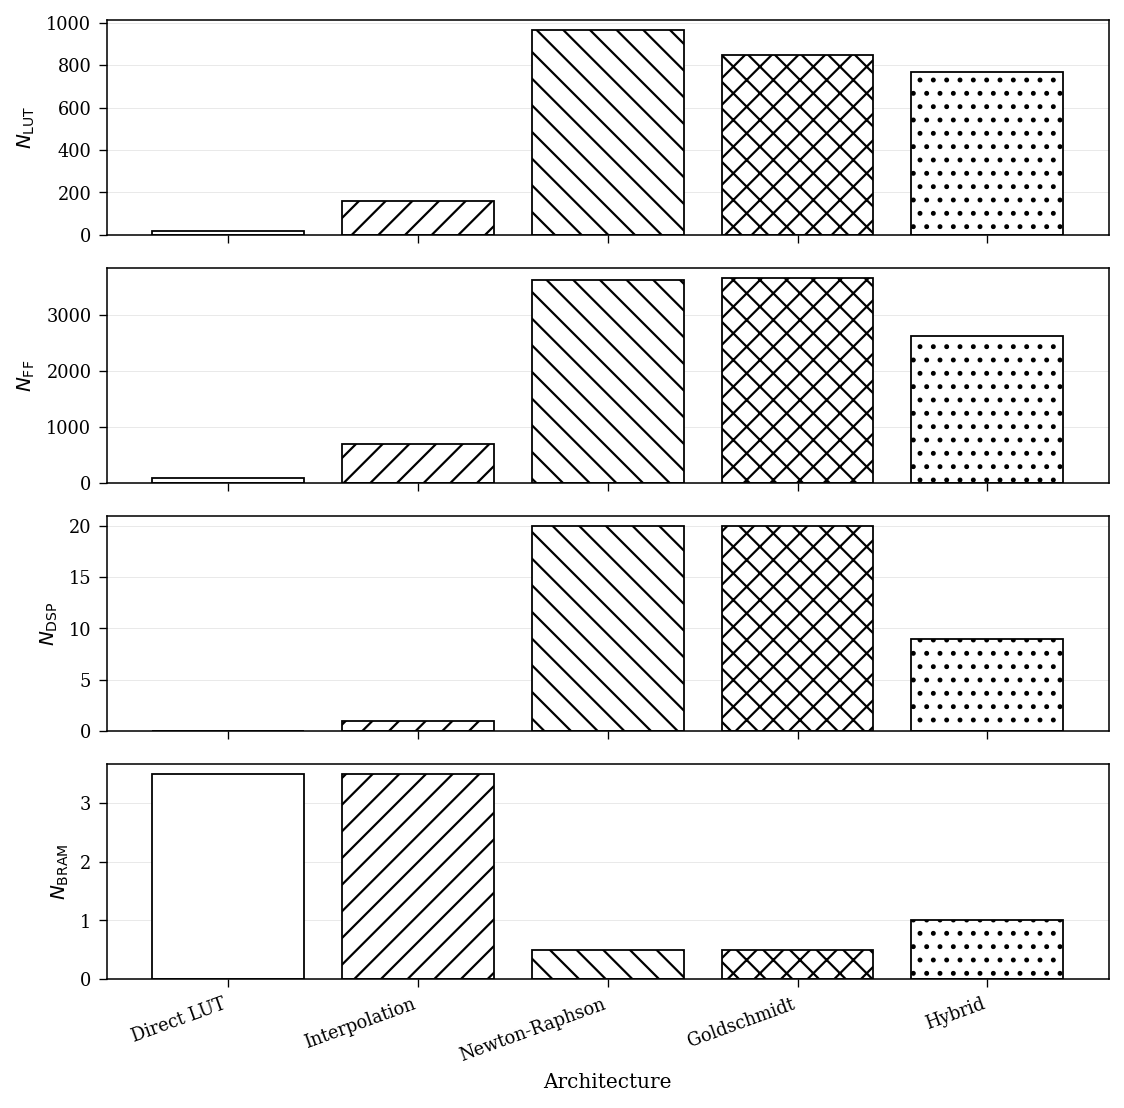

In [10]:
df_resource = pd.DataFrame({
    "Architecture": [
        "Direct LUT",
        "Interpolation",
        "Newton-Raphson",
        "Goldschmidt",
        "Hybrid"
    ],
    "LUT": [
        19,
        159,
        966,
        846,
        768
    ],
    "FF": [
        84,
        685,
        3612,
        3656,
        2626
    ],
    "DSP": [
        0,
        1,
        20,
        20,
        9
    ],
    "BRAM": [
        3.5,
        3.5,
        0.5,
        0.5,
        1
    ]
})

metrics = [
    ("LUT", r"$N_{\mathrm{LUT}}$"),
    ("FF", r"$N_{\mathrm{FF}}$"),
    ("DSP", r"$N_{\mathrm{DSP}}$"),
    ("BRAM", r"$N_{\mathrm{BRAM}}$")
]

hatches = [
    "",
    "//",
    "\\",
    "xx",
    ".."
]

fig, axes = plt.subplots(
    4,
    1,
    figsize=(7.1, 7.0),
    sharex=True
)

for ax, (metric, ylabel) in zip(
    axes,
    metrics
):
    bars = ax.bar(
        df_resource["Architecture"],
        df_resource[metric],
        color="white",
        edgecolor="black",
        linewidth=0.8
    )
    for bar, hatch in zip(
        bars,
        hatches
    ):
        bar.set_hatch(hatch)
    ax.set_ylabel(ylabel)
    ax.grid(
        axis="y",
        linewidth=0.35,
        alpha=0.35
    )
    ax.set_axisbelow(True)

axes[-1].set_xlabel(
    "Architecture"
)

plt.xticks(
    rotation=20,
    ha="right"
)

fig.tight_layout()

fig.savefig(
    "fig8_resource_utilization.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

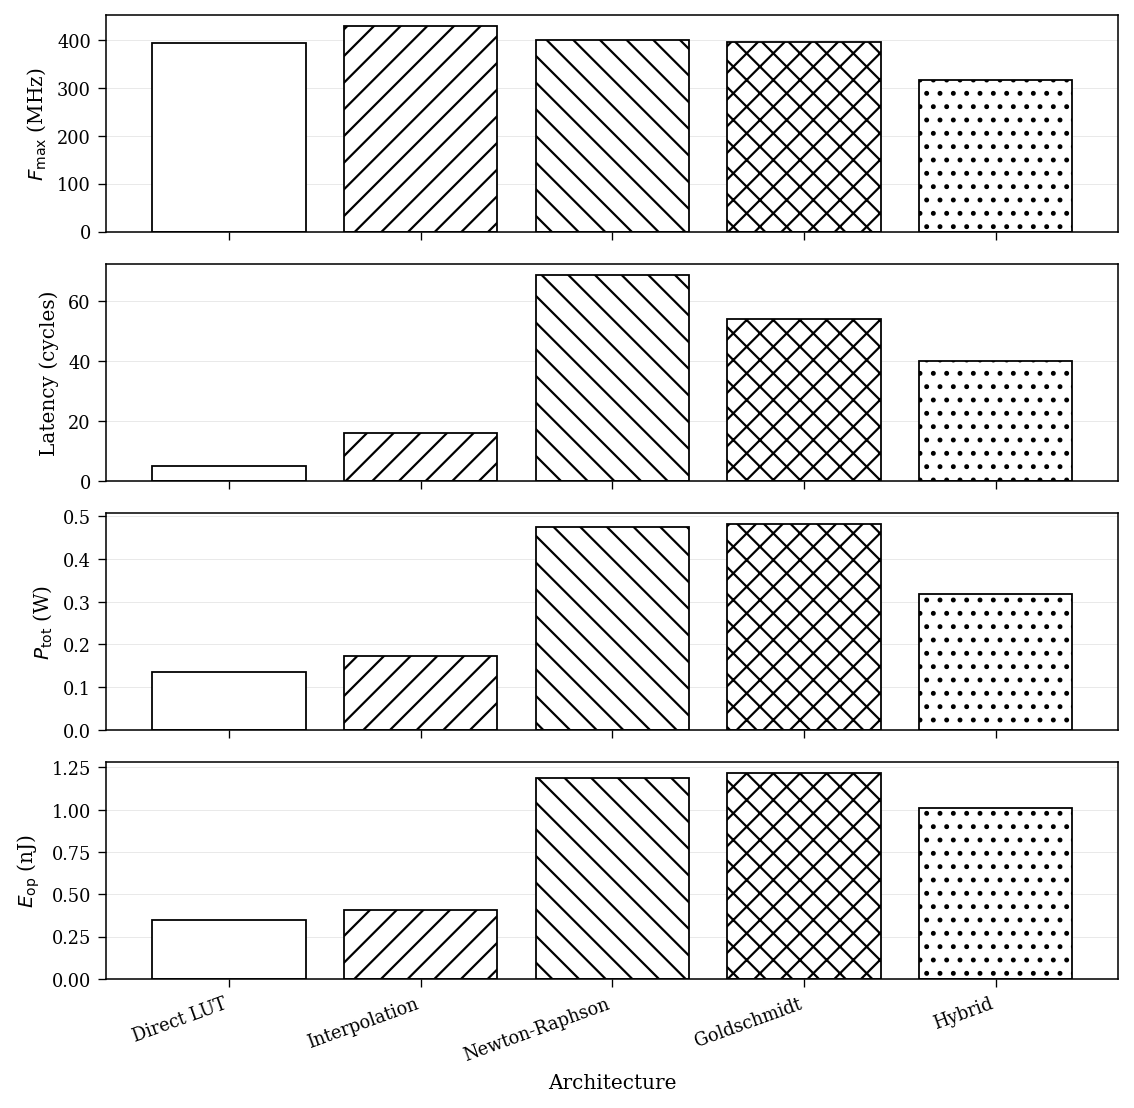

In [11]:
df_perf = pd.DataFrame({
    "Architecture": [
        "Direct LUT",
        "Interpolation",
        "Newton-Raphson",
        "Goldschmidt",
        "Hybrid"
    ],
    "Fmax": [
        392.772977,
        429.737860,
        399.201597,
        396.353547,
        316.055626
    ],
    "Latency": [
        5,
        16,
        69,
        54,
        40
    ],
    "Power": [
        0.136,
        0.174,
        0.475,
        0.483,
        0.319
    ],
    "Energy": [
        0.346256,
        0.404898,
        1.189875,
        1.218609,
        1.009316
    ]
})

metrics = [
    ("Fmax", r"$F_{\mathrm{max}}$ (MHz)"),
    ("Latency", "Latency (cycles)"),
    ("Power", r"$P_{\mathrm{tot}}$ (W)"),
    ("Energy", r"$E_{\mathrm{op}}$ (nJ)")
]

fig, axes = plt.subplots(
    4,
    1,
    figsize=(7.1, 7.0),
    sharex=True
)

for ax, (metric, ylabel) in zip(
    axes,
    metrics
):
    bars = ax.bar(
        df_perf["Architecture"],
        df_perf[metric],
        color="white",
        edgecolor="black",
        linewidth=0.8
    )
    for bar, hatch in zip(
        bars,
        hatches
    ):
        bar.set_hatch(hatch)
    ax.set_ylabel(ylabel)
    ax.grid(
        axis="y",
        linewidth=0.35,
        alpha=0.35
    )
    ax.set_axisbelow(True)

axes[-1].set_xlabel(
    "Architecture"
)

plt.xticks(
    rotation=20,
    ha="right"
)

fig.tight_layout()

fig.savefig(
    "fig9_performance_power.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()